# Task 2 — The agent and its evaluation

I built an agent that uses selective organizational memory to find useful history and
graph tools to inspect the evidence behind it. This notebook explains why I made those
choices and how I evaluate **BM25 text RAG, graph-only, and memory+graph** on six questions
with repeats and paraphrases. The full [methodology](METHODOLOGY.md#task-2-agent-methodology)
connects these choices to Task 1.

**Current conclusion:** the final experiment in `final-sol-v2` has **54 saved answers,
54 answer judgments and 36 consistency comparisons**, using a **200,000-character**
cap for all three systems. Automated scoring finds higher coverage for memory+graph
(68.9%) than text RAG (58.9%) or graph-only (53.4%). Memory+graph has lower groundedness
than text RAG (93.0% versus 95.7%) and higher mean answer latency (66.1 versus 26.2 seconds).
These are measured trade-offs on six development-exposed questions, not a general win.
The report is `automated_only`; no human answer audit has been imported.

The first pilot remains local under `pilot-sol-v1`: six attempts and judging, with one
BrightData graph-only failure at the original 48,000-character cap. The proposed
`pilot-sol-v2` rerun was not performed before the final experiment.

**Execution is artifact-only:** no model calls, memory construction, report generation,
or synthetic fallback occurs when running these cells. Missing answers and scores stay
missing. The live CLI commands appear below; completed results can then be displayed by
rerunning the notebook.

The reference checklist was accepted under the user's explicit instruction,
**“Let's assume they are correct.”** Exact citations are programmatically validated;
this does not constitute human source review or an authoritative gold answer key.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd()))
import html
import json
from collections import Counter
from IPython.display import display, Markdown, HTML, Image
from org_agent.models import AnswerResult
from org_agent.artifacts import SourceArtifacts
from org_eval.benchmark import load_frozen, review_basis
from org_eval.common import read_json
from org_eval.corpus import TextCorpus
from org_eval.notebook import claim_rows, trace_rows, ranking_exclusions, load_saved_results
from org_eval.runner import preflight, read_answer

RESULTS = Path('artifacts/evaluation/final-sol-v2')
GRAPH = RESULTS / 'inputs' / 'graph.json'
MEMORY = Path('artifacts/memory/memory.json')
BENCHMARK_DIR = Path('artifacts/evaluation/benchmark')
BENCHMARK = BENCHMARK_DIR / 'benchmark.frozen.json'
PILOT = Path('artifacts/evaluation/pilot-sol-v2')
LIVE_CHECK = Path('artifacts/task2/sol-pilot-check-v2')
PREFLIGHT = Path('artifacts/evaluation/preflight-sol-v2')
ANSWER_MODEL = 'gpt-6-sol'
JUDGE_MODEL = 'gpt-6.1-sol'
MAX_REQUEST_CHARS = 200000
APPROACHES = ('text_rag', 'graph_only', 'memory_graph')

def show_table(rows):
    if not rows:
        display(Markdown('_No observations available._'))
        return
    keys = list(dict.fromkeys(k for row in rows for k in row))
    def value(v):
        if v is None:
            return 'unknown / not measured'
        if isinstance(v, float):
            return f'{v:.4f}'
        if isinstance(v, (dict, list)):
            return json.dumps(v, ensure_ascii=False)
        return str(v)
    head = '<tr>' + ''.join('<th>' + html.escape(k) + '</th>' for k in keys) + '</tr>'
    body = ''.join('<tr>' + ''.join('<td>' + html.escape(value(row.get(k))) + '</td>'
                                   for k in keys) + '</tr>' for row in rows)
    display(HTML('<div class="task2-table"><table>' + head + body + '</table></div>'))

display(HTML('<style>.task2-table{overflow:auto;margin:12px 0;max-width:100%}'
             '.task2-table table{border-collapse:collapse;font-size:13px}'
             '.task2-table td,.task2-table th{border:1px solid #ccc;padding:8px;text-align:left;'
             'vertical-align:top;white-space:pre-wrap;min-width:100px;max-width:520px;overflow-wrap:anywhere}'
             '.task2-table th{background:#edf2f7;color:#18232f}</style>'))
source = SourceArtifacts.load(GRAPH)
corpus = TextCorpus(source)
benchmark = load_frozen(BENCHMARK, corpus) if BENCHMARK.exists() else read_json(BENCHMARK_DIR / 'benchmark.draft.json')
memory_check = preflight(GRAPH, MEMORY)
memory = read_json(MEMORY)
manifest, run_benchmark, evaluation = load_saved_results(RESULTS)
if run_benchmark:
    benchmark = run_benchmark

## Current execution state

Production memory is structurally complete. Structural validity establishes provenance
and schema integrity, not the correctness of the stored abstractions. The source corpus
consists of extracted record passages preserved in the supplied graph, not full external
tickets. No outside organizational history is supplied to the systems.

I freeze the completed memory before comparing answers so that the input cannot change
in response to final scores. All 816 eligible base candidates and 23 abstraction packets
were processed; this does not mean every candidate was accepted or every outcome observed.
I selected the unchanged Astra pattern layer over the Luna-built base after the
local qualitative comparison (`artifacts/reviews/abstraction-model-comparison.json`) favored its
distinctions and counterevidence while recording overstatements. That inspection assessed
abstractions, not downstream QA performance.

In [2]:
show_table([{
    'memory_ready': memory_check['production_memory_ready'],
    'episodes': len(memory['episodes']), 'facts': len(memory['facts']),
    'patterns': len(memory['patterns']), 'outcomes': len(memory['outcome_assessments']),
    'source_records': len(corpus.records), 'source_passages': sum(len(r['passages']) for r in corpus.records),
    'memory_fingerprint': memory_check.get('memory_identity', {}).get('memory_fingerprint'),
    'benchmark_status': benchmark['status'],
    'reference_basis': review_basis(benchmark['review']) if 'review' in benchmark else 'draft',
    'answer_model': ANSWER_MODEL, 'judge_model': JUDGE_MODEL,
    'selected_max_request_chars': MAX_REQUEST_CHARS,
}])
live = read_json(LIVE_CHECK / 'answer.json') if (LIVE_CHECK / 'answer.json').exists() else None
probe = read_json(PREFLIGHT / 'preflight.json') if (PREFLIGHT / 'preflight.json').exists() else None
show_table([
    {'stage': 'Standalone live answering check', 'status': live['status'] if live else 'not_bundled',
     'detail': live.get('stop_reason') if live else None},
    {'stage': 'Judge provider check', 'status': (probe or {}).get('provider_probe', {}).get('status', 'not_bundled'),
     'detail': (probe or {}).get('provider_error')},
    {'stage': 'Pilot rerun at 200,000 characters', 'status': read_json(PILOT / 'progress.json')['status'] if (PILOT / 'progress.json').exists() else 'not_run',
     'detail': 'The original 48,000-character pilot remains in pilot-sol-v1; the proposed rerun was skipped'},
    {'stage': 'Final comparison', 'status': evaluation['status'] if evaluation else 'not_scored' if manifest else 'not_run',
     'detail': 'Six questions × three systems × three variants = 54 answers'},
])
if evaluation is None:
    display(Markdown('**No real comparative scores are available. No conclusion about memory value is established.**'))

memory_ready,episodes,facts,patterns,outcomes,source_records,source_passages,memory_fingerprint,benchmark_status,reference_basis,answer_model,judge_model,selected_max_request_chars
True,653,1086,46,791,901,2322,memory_e4d06d4e2b5f1072,frozen,user_assumption,gpt-6-sol,gpt-6.1-sol,200000


stage,status,detail
Standalone live answering check,not_bundled,unknown / not measured
Judge provider check,not_bundled,unknown / not measured
"Pilot rerun at 200,000 characters",not_run,"The original 48,000-character pilot remains in pilot-sol-v1; the proposed rerun was skipped"
Final comparison,automated_only,Six questions × three systems × three variants = 54 answers


## Task 2 requirements and available evidence

This table records the completed automated experiment and its remaining limitations.
The saved status tables and results below provide the measurements. The CLI workflow reproduces experiments;
running this notebook alone reads and validates artifacts rather than creating answers.

| Requirement | Implemented or available | Limitation or follow-up |
|---|---|---|
| Agent chooses graph and memory tools | Nine tools, an adaptive action loop and saved live traces | Three runs finalized without retrieving evidence |
| Explicit working memory | 200,000-character projection, pins, discards, eviction reasons and budgets | One run exhausted its data-tool allowance |
| Claims, provenance, trace, and confidence | 369 claims across 54 answers; exact citations and JSONL traces | All answers are partial; three contain no claims |
| At least four questions across required capabilities | Six final questions, three systems and three variants: 54 answers | Development exposure; the revised pilot was skipped |
| RAG comparison on coverage, groundedness, specificity, consistency, and cost | 54 automated judgments and 36 consistency comparisons | Human answer audit remains outstanding |
| Runnable code and inline outputs | Executed artifact readers, final answer tables, quality/cost charts and traces | Model/provider access is needed only to repeat the live experiment |
| Design rationale and final reflection | Measured gains, regressions and cost trade-offs below | Individual memory components have not been isolated by ablations |

Missing results remain missing. Synthetic pipeline tests verify implementation behavior;
the measurements displayed here come from the saved real experiment.

## Agent design and working memory

I use a single LangChain agent to keep action selection flexible while making every
evidence access auditable. A JSON adapter exposes the registered read-only tools and the
final `DraftAnswer` action; each model call selects one action. The model chooses the tool
order. A narrow record question can start with the graph, while a comparative question can
start with memory. There is no enforced memory-first workflow.

| Memory tool | Contribution and reason |
|---|---|
| `recall_memory` | Compact entry points from a partial cue, avoiding repeated discovery of related records |
| `inspect_memory` | Scoped facts, original passages, uncertainty and counterevidence behind a selected item |
| `list_patterns` | Previously computed comparisons across records, with support counts and limits |
| `list_outcomes` | Outcome assessments, including those outside accepted episodes; impact is ordinal |
| `memory_timeline` | Explicit dated mentions separated from unplaced evidence, avoiding invented ticket chronology |

| Graph tool | Contribution and reason |
|---|---|
| `search_graph` | Original passages and distinct entities, including records omitted from selected memory |
| `graph_neighborhood` | Local connections with their original direction and provenance |
| `graph_paths` | Bounded paths to investigate possible connections; connectivity does not prove cause |
| `get_evidence` | Exact source slices and character offsets for detail and citation checking |

Memory contributes selection and abstraction; graph access lets the agent test a remembered
interpretation against original detail. Both can expose the same passage, so reopening a
memory item's source is not independent corroboration. Avoiding rediscovery could save
time, but speed is an empirical question. The agent is instructed to inspect original graph
evidence for causes, claimed fixes and chronology. Plans, routines and closed tickets do
not prove execution or recovery; a `CAUSES` link does not prove a cause. These semantic
rules guide the model and are assessed separately from exact citation checks.

**Why this recall method.** BM25 supplies lexical matches; existing node vectors and bounded
memory associations expand useful entry points. Because the supplied embedding encoder is
unknown, query vectors come from lexically matched node labels, not newly embedded free text
in an incompatible space. Rank fusion, confidence weights and association decay are
heuristics, and missing lexical anchors can still cause misses. Terminology aliases expand
vocabulary without merging tenants or environments, and common hubs are discounted.
Default recall omits compressed episodes; callers can include them explicitly. Duplicate facts with the
same text, scope and kind and results outside the retrieval limit receive exclusion reasons.

**Working memory policy.** Every question starts with fresh conversational state. The
context begins with the question, instructions, artifact identity and tool/action schemas.
Discovery adds compact cards or excerpts; inspection adds selected source slices. Pagination
makes further detail an explicit choice. The agent can pin seen supporting evidence and
counterevidence and discard seen memory cards with reasons. Before each model call,
projection removes discarded cards unless protected by pins, removes older duplicate
exchanges, then evicts the oldest unpinned whole exchanges until the request fits
**200,000 canonical serialized characters**. Keeping exchanges whole preserves call/result
pairs. The question, pinned evidence and newest remaining exchange are preserved; if they
cannot fit, answering stops explicitly. This measures application input, not model tokens
or the complete provider wire payload. There is no generated rolling summary to rewrite quotes.
Both `run_task2.py` and `run_evaluation.py run` accept `--max-request-chars`; 200000
is the default. Changing the cap requires a new experiment output directory.

The full ledger lives outside model context. Citation validation remembers spans shown on
earlier calls, even after eviction, while context events show what entered each request.
The same full trace is streamed to disk during execution and retained in the final answer.

**Why stop.** Retrieval ends at ten data-tool calls, three successive calls adding no new
item/node/evidence/span, or when only two of twelve model calls remain for finishing and
correction. Reading a new source page counts as progress. These pragmatic limits bound
repeated searching and leave room for a partial answer; they are not empirically optimal.
Invalid citations receive at most one correction from already-seen sources, without more
retrieval. Remaining invalid claims are excluded; errors, missing evidence and budget stops
stay visible. Model calls include repairs and cache reads.

## Answer contract and evidence trace

Each answer contains up to twelve atomic claims, with a kind (`source_report`,
`prescription`, `synthesis`, or `hypothesis`), exact evidence quotations and offsets,
relevant memory IDs, and confidence with a reason. The application derives record IDs
and source routes, checking access and support links. A brief verification note explains
the evidence relationship. Unanswered aspects and limitations remain separate so that
insufficient evidence need not become an invented conclusion.

| Source route | Meaning |
|---|---|
| `memory` | Linked memory items were used; not every cited span was also accessed through graph tools |
| `graph` | No memory item is attributed and graph evidence was accessed |
| `memory_confirmed_by_graph` | Memory items were used and every cited span was also shown through a graph tool |
| `text` | The baseline used retrieved source text without memory attribution |

Memory IDs are declared by the model and checked against actual access and evidence links.
Routes describe that access, not all possible influences on the model. Each claim needs
substantive extracted support: labels, inferred rationales and administrative closure alone
are insufficient. Exact source access still does not establish semantic entailment.

High confidence means unambiguous direct support, medium means qualified synthesis, and low
means a hypothesis or unresolved conflict. Hypotheses must mechanically have low confidence;
the other confidence judgments depend on the model. Labels are not calibrated probabilities,
and confidence calibration is not an evaluation metric here.

I interpret the requested reasoning trace as an execution and evidence trace: action purpose,
tool arguments and results, recalled items, pinned evidence, ranking exclusions, explicit
relevance discards, and context evictions with reasons. These events distinguish retrieval
limits from model relevance decisions and context pressure. Brief verification notes connect
evidence to claims; the trace does not expose private chain-of-thought. An absent discard
event means no such decision was recorded, not that an explanation should be invented.

## Questions, reference criteria and fairness

I use an evidence-linked checklist because there are no authoritative gold answers. It
specifies essential facts, distinctions, justified uncertainties and tempting unsupported
conclusions without prescribing one model answer. Reference preparation combines seed
records and BM25 searches, preserving queries, included records and packet omissions.
Each question has four to eight facets with exact quotations and an `any`/`all` evidence
rule. The frozen set has 43 facets: 33 for final questions and ten for pilots.

The saved generation metadata records authorship by the coding assistant from inspected
excerpts after the configured SDK drafting call failed. Its `user_assumption` review basis
reflects “Let's assume they are correct,” not human semantic review or exhaustive source
coverage. Exact quotations and offsets were validated. Freezing prevents criteria changing
silently in response to answers; it does not establish reference correctness.

The six final questions cover recurring processing failures, the government narrative outage,
DocDB/Elasticsearch gaps, April collection chronology, monitoring/QA routines, and pruning.
Chronology is tested both where dates exist and where ordering remains uncertain. Two separate
pilots test Weibo validation/retest conflicts and BrightData migration plans versus outcomes.

These are **known-corpus diagnostic questions**. Assignment examples, abstraction themes
and development records overlap with them. This comparison does not establish performance
on unseen organizations or questions. Pilots are excluded from final scores. Human answer
judgment auditing is a separate stage from accepting the benchmark under an assumption.

In [3]:
show_table([{'id': q['id'], 'split': q['split'], 'category': q['category'], 'question': q['text'],
             'paraphrase': q['paraphrase'], 'facets': len(q['facets']), 'development_exposure': q['exposure']}
            for q in benchmark['questions']])
display(Markdown(f'[Full source checklist]({BENCHMARK_DIR / "benchmark.review.html"}) · '
                 f'[Frozen benchmark]({BENCHMARK}) · [Assumption record]({BENCHMARK_DIR / "benchmark.assumption.json"})'))
q = next(q for q in benchmark['questions'] if q['id'] == 'government')
show_table([{'facet': f['id'], 'kind': f['kind'], 'criterion': f['description'],
             'records': ', '.join(sorted({source.index['evidence'][r['evidence_id']]['record_id'] for r in f['evidence']})),
             'exact_evidence': '\n\n'.join(r['quote'] for r in f['evidence'])} for f in q['facets']])

id,split,category,question,paraphrase,facets,development_exposure
patterns,final,patterns,"Which processing failure modes recur across narrative generation and collection, and where do the mechanisms differ?","Across narrative and collection processing, what reported failure mechanisms recur, and which differences prevent treating them as one cause?",5,Reliability was an abstraction theme; April incidents were development examples.
government,final,root_cause,"Why did the government tenant stop receiving narrative updates in April 2026, and what did the timeout change actually address?","For the April 2026 government-network narrative outage, what failed and how much of the problem did increasing the timeout resolve?",6,Assignment example and existing development reference case.
data_gaps,final,root_cause,"What explanations do the records support for DocDB/Elasticsearch data gaps, and what remains unresolved?","What can we infer from the DocDB and Elasticsearch gap reports about their explanations, and which explanations remain uncertain?",5,Assignment example and abstraction theme; inspected in development.
collection_timeline,final,change_over_time,"How did the April collection incident progress from reported failures through remediation and backfill, and what recovery is verified?","Trace the reported April collection failures, subsequent technical changes and backfill actions; what evidence confirms recovery?",7,Collection outage was a development example; chronology is evaluated separately.
routines,final,routines,"Which monitoring and QA activities are documented routines, and what evidence shows they were performed or effective?","What does the history say teams should routinely do for monitoring and QA, and what establishes actual execution or effectiveness?",5,Routines were an abstraction theme and development reference case.
pruning,final,uncertain_chronology,"What changes in narrative pruning behavior and remediation are documented, and how confidently can they be ordered?","Which pruning behaviors and follow-up actions are reported, and what evidence supports their temporal order?",5,Assignment example and abstraction theme; no explicit dates found in inspected records.
pilot_weibo,pilot,source_conflict,What do the Weibo hashtag validation and retest records establish about the defect and its resolution?,"From the Weibo hashtag bug and retesting excerpts, what is supported about the observed behavior and whether it was fixed?",5,Existing development inspection; tuning only.
pilot_brightdata,pilot,plans_and_outcomes,"What do the account-generation records establish about the BrightData migration's motivation, implementation and verified outcome?","For account generation, why was a BrightData migration discussed, what work was specified, and what outcome is actually demonstrated?",5,Existing development reference case; tuning only.


[Full source checklist](artifacts/evaluation/benchmark/benchmark.review.html) · [Frozen benchmark](artifacts/evaluation/benchmark/benchmark.frozen.json) · [Assumption record](artifacts/evaluation/benchmark/benchmark.assumption.json)

facet,kind,criterion,records,exact_evidence
F1,fact,"Scope the reported interruption to at least one government customer network in the Argonaut tenant, starting approximately April 19, 2026.",KEP-6969,"A government customer network in the Argonaut tenant (network_id: ca95298f-cb34-5119-b8f9-e447607dfab7) stopped generating narrative updates from approximately April 19, 2026"
F2,fact,The source attributes job termination to exceeding the ten-hour processing SLA threshold.,KEP-6969,Root cause: narrative generation jobs for this network were repeatedly running beyond the processing time SLA threshold (10 hours at the time) and being killed by the application before completing
F3,fact,Repeated requeueing and termination produced a retry loop with no output.,KEP-6969,"The same job would then re-queue and be killed again, creating a silent retry loop with no output and no alert"
F4,fact,The customer discovered the problem; alarms later detected it but no action was taken.,KEP-6969,"A government customer network in the Argonaut tenant (network_id: ca95298f-cb34-5119-b8f9-e447607dfab7) stopped generating narrative updates from approximately April 19, 2026. The issue was not caught by any internal alarm — it was discovered by the government customer's own team, then, when the issue continued, our alarms caught it but no action was taken. Root cause: narrative generation jobs for this network were repeatedly running beyond the processing time SLA threshold (10 hours at the time) and being killed by the application before completing."
F5,fact,The reported intervention increased the timeout from ten to twelve hours.,KEP-6969,the processing timeout was increased from 10 hours to 12 hours
F6,uncertainty,"Increasing the threshold addresses a termination condition; these excerpts do not verify recovery, explain the underlying workload duration, or establish improved detection/response.",KEP-6969,Root cause: narrative generation jobs for this network were repeatedly running beyond the processing time SLA threshold (10 hours at the time) and being killed by the application before completing the processing timeout was increased from 10 hours to 12 hours


### Comparison controls and their limits

I include graph-only to distinguish the contribution of memory access from the combined
system's performance against text RAG. The text baseline performs one BM25 retrieval of
up to twenty positive-scoring records and one generation, with at most one citation/format
correction. Duplicate passages within
a record are collapsed while preserving equivalent evidence references. Whole records are
packed in rank order; records that do not fit are logged as omitted, and later candidates
can still fit. It sees extracted text without memory, graph labels or inferred links. BM25
is an inspectable standard baseline; it does not represent dense, reranked or iterative RAG.

Graph-only exposes the four graph tools and never loads memory or builds memory indexes.
Memory+graph adds the five memory tools and memory-derived terminology expansion.
All three systems use **gpt-6-sol, medium reasoning**, shared evidence rules and the same
200,000-character cap. Both agents have identical call limits. Online execution costs are
measured rather than equalized: additional retrieval may buy quality at additional expense.
Different schemas/prompts occupy different portions of the cap, so equal limits do not
guarantee equal source-text allowances. Pass the selected model flags explicitly; CLI
defaults differ.

Memory+graph versus graph-only measures the memory package, including vocabulary expansion
and changed tool/prompt affordances. It cannot isolate the contribution of patterns, facts,
impact scores or any single recall mechanism. The text-RAG comparison measures the combined
approach. The observed differences below apply to this benchmark and configuration.

Seed **20261006** varies question and system order within each variant block. Each answer
starts with fresh conversation state and has its own response cache; the identical repeat
cannot replay the original answer's cache. Original, repeat and paraphrase yield 54 final
answers and 36 comparisons against originals. Code, source, memory, benchmark and settings
are fingerprinted. Resume skips completed answers, including failures; changed inputs or
retries of saved failures require a new experiment directory.

### Semantic judging

A separate **gpt-6.1-sol**, medium reasoning, scores anonymous answers using their cited
passages and original context from cited/reference-pool records. System identity, routes,
memory IDs and tool histories are hidden. This reduces explicit system preference, although
writing style may still reveal clues and the judge remains fallible.

The judge splits compound claims into propositions and asks whether each proposition's
**own citations** support it. A different source in the reference packet cannot repair a
bad citation. Verdicts are supported, partial, unsupported or contradicted. Equivalent
supported answers can satisfy facets; useful material outside the checklist is flagged as
a reference omission rather than automatically changing the scoring denominator. The
later human audit preserves original judgments and records attributable overrides.

## Reproduce the live comparison

Run these commands from the project root in a runtime where the Codex SDK can start and
authenticate. The notebook does not execute them. Both probes must succeed before launching
the matrix. Historical startup failures remain under `artifacts/task2/sol-pilot-check`.
Use a fresh smoke output path and cache for each retry.

The saved final experiment used `final-sol-v2`. The commands below use fresh
`reproduction-*` directories and the same 200,000-character cap. The bundled manifests
retain the original code fingerprint; they must not be edited to resume with changed
code. Recomputing the saved report is supported without rerunning providers.

```bash
cp artifacts/evaluation/final-sol-v2/inputs/graph.json KEP_2026.json
python run_task2.py \
  --graph KEP_2026.json --memory artifacts/memory/memory.json \
  --model gpt-6-sol --question "What do the Weibo hashtag validation and retest records establish about the defect and its resolution?" \
  --output artifacts/task2/reproduction-check --cache-dir artifacts/task2/reproduction-check/cache
python run_evaluation.py preflight \
  --memory artifacts/memory/memory.json --check-provider \
  --judge-model gpt-6.1-sol --output artifacts/evaluation/reproduction-preflight
python run_evaluation.py run --split pilot \
  --memory artifacts/memory/memory.json --model gpt-6-sol --max-request-chars 200000 \
  --output artifacts/evaluation/reproduction-pilot --max-calls 100
python run_evaluation.py judge --judge-model gpt-6.1-sol \
  --output artifacts/evaluation/reproduction-pilot --max-calls 30
python run_evaluation.py report --output artifacts/evaluation/reproduction-pilot
```

Inspect the six pilots, then freeze implementation and settings. Do not tune against final
answers. Continue with:

```bash
python run_evaluation.py run \
  --memory artifacts/memory/memory.json --model gpt-6-sol --max-request-chars 200000 \
  --output artifacts/evaluation/reproduction-final --max-calls 600
python run_evaluation.py judge --judge-model gpt-6.1-sol \
  --output artifacts/evaluation/reproduction-final --max-calls 200
python run_evaluation.py audit-export --output artifacts/evaluation/reproduction-final
python run_evaluation.py report --output artifacts/evaluation/reproduction-final
```

Call caps are cumulative per stage, including failed attempts and cache lookups. Rerun
unchanged commands to resume; raise the cap if it was exhausted. `run --max-runs N`
checkpoints after N additional answers. Never interpret a stage marked complete as proof
that every answer succeeded. After any new answers, judgments or audit, regenerate the report.

## Evaluation results

I report separate dimensions rather than one overall winner so that an answer's breadth
cannot conceal weak support, and additional detail cannot conceal additional cost.

| Dimension | Definition |
|---|---|
| Coverage | Mean essential-facet score: 0 missing/contradicted, 0.5 partial, 1 supported and complete |
| Groundedness | Fraction of atomic propositions fully supported by their own citations; partial and contradicted propositions remain visible |
| Specificity | Supported-detail rubric from 0 to 4, including appropriate scope and uncertainty |
| Consistency | Jaccard overlap of fully covered facet sets, and contradiction rate among comparable proposition pairs, for originals versus repeats/paraphrases; internal contradictions counted separately |
| Cost | Input/output tokens, model calls, data-tool calls and answering wall time; index/setup, construction and judging reported separately |

Specificity anchors are: **0** no useful supported detail; **1** topic only; **2** scoped
systems and symptoms/routines; **3** supported mechanisms/actions/outcomes; **4** a precise
account with material scope, chronology, causality, execution or uncertainty distinctions.
Unsupported detail earns no credit. Factual facets need supported or partly supported
claims, while uncertainty facets may be addressed in limitations or unanswered aspects.

Exact quotation validity is a structural check, separate from semantic grounding. Partial
grounding verdicts stay in the denominator but do not count as fully supported. Empty
answers have undefined groundedness; a failed run receives zero coverage and specificity,
while an unrun question stays missing. Empty facet unions and absent comparable proposition
pairs yield undefined consistency, not perfect agreement. Two wrong answers can be consistent.

Unknown usage is not zero; available usage is retained as a lower bound. Cached-input and
reasoning-token counts are subsets of input/output totals. Response-cache replays are
excluded from fresh-cost aggregates. Amortized construction cost at 10, 100 and 1,000
questions is an accounting scenario, shown only when build and online usage are available.
Dollar cost is not inferred from subscription access.

Variants are averaged within questions first: six questions remain six evaluation units.
Memory+graph versus text RAG measures the combined system. Memory+graph versus graph-only
measures the contribution of the memory package. Positive cost differences mean greater
cost. Means exclude undefined values, so inspect completion counts and individual runs;
missing variants can make comparisons uneven. I interpret these small-sample differences
descriptively, without significance claims or treating repeats as independent questions.

**Report status: automated_only**

approach,questions,scheduled_runs,finished_runs,failed_runs,judged_runs,fresh_cost_runs,answers_with_grounding_score,coverage,groundedness,specificity,input_tokens,output_tokens,model_calls,tool_calls,latency_seconds
text_rag,6,18,18,0,18,18,18,0.5893,0.9569,3.8333,8807.1111,1921.5556,1,1,26.2368
graph_only,6,18,18,0,18,18,16,0.5343,0.9474,3.5000,81608.8333,2437.2222,6.3889,5.2778,52.1133
memory_graph,6,18,18,0,18,18,17,0.6893,0.9301,3.7222,119674.0000,3303.2222,7.5556,6.2778,66.1216


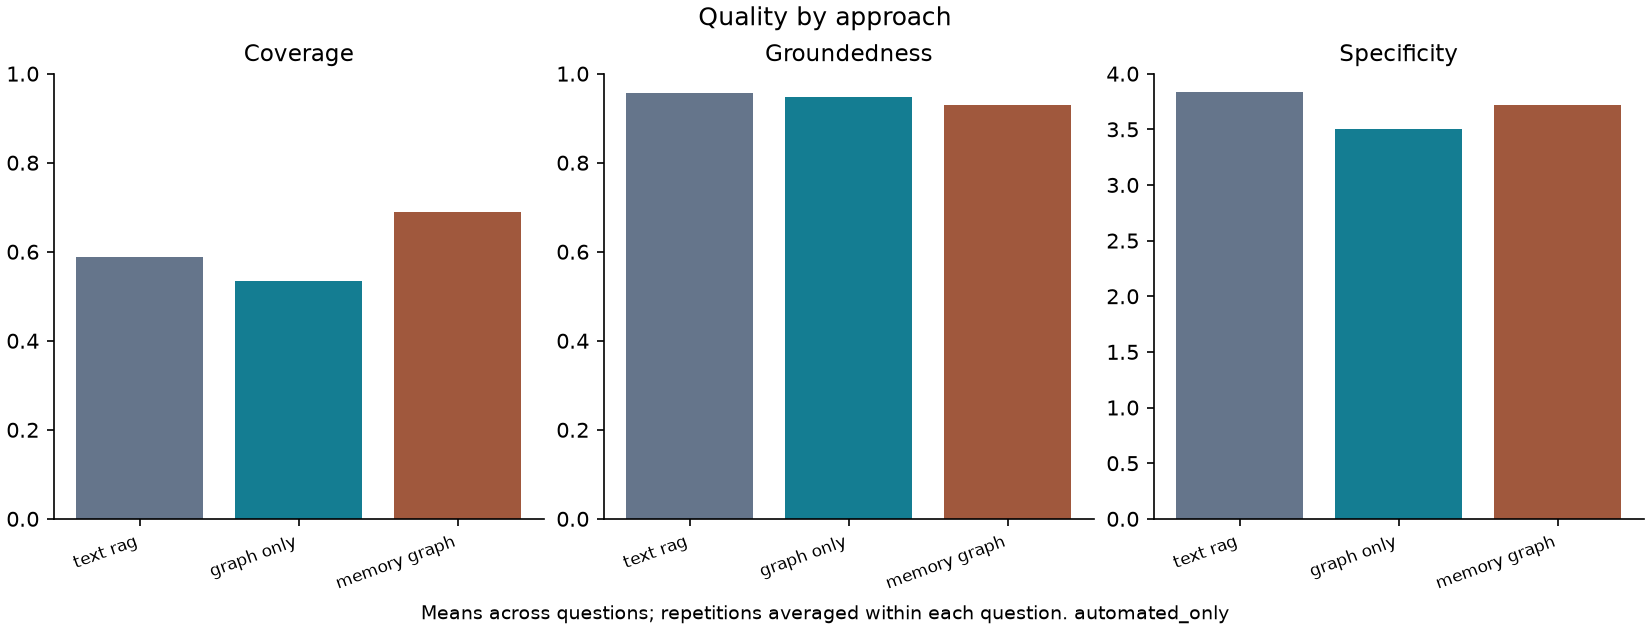

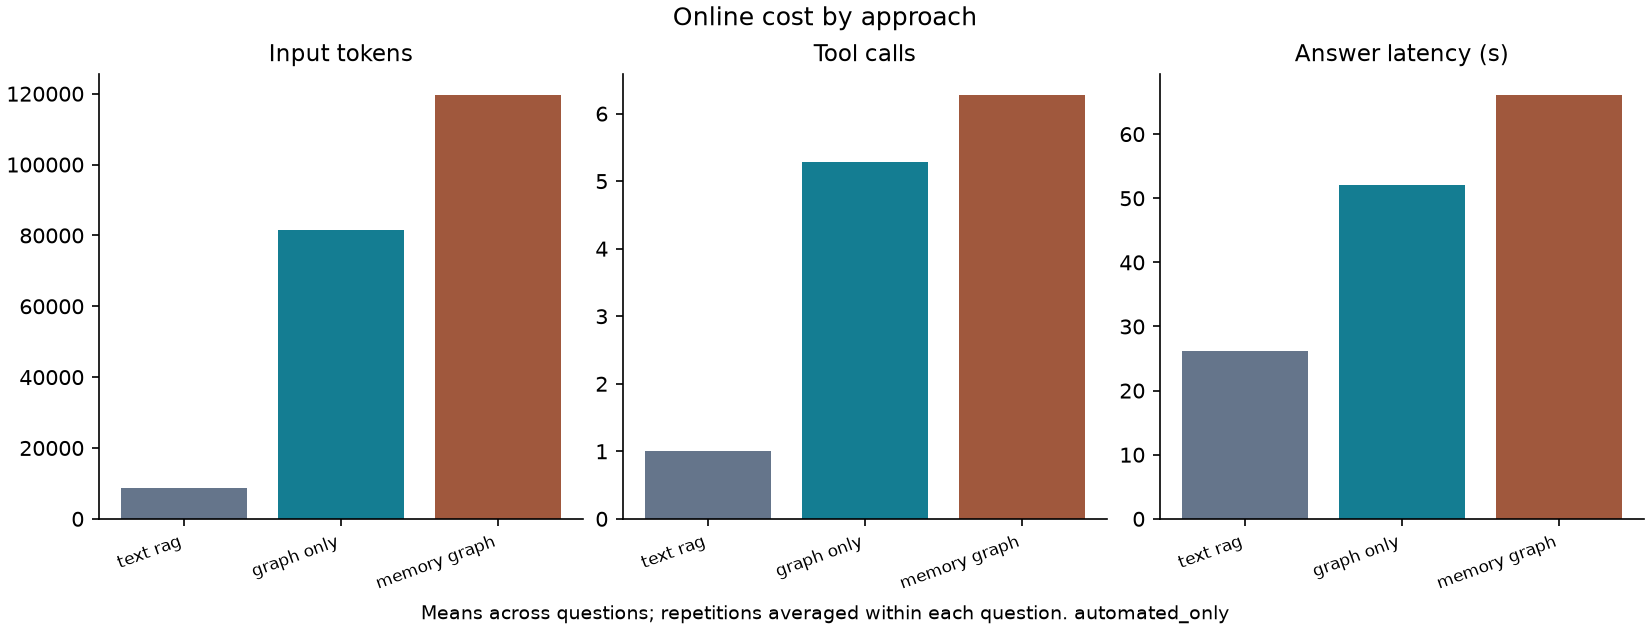

run_id,question_id,approach,variant,status,judged,human_audited,coverage,groundedness,specificity,citation_validity,internal_contradictions,input_tokens,output_tokens,model_calls,tool_calls,latency_seconds,cache_replays,fresh_measurement
pruning__original__graph_only,pruning,graph_only,original,partial,True,False,0.6000,1.0000,4,1.0000,0,33910,2522,4,3,40.6660,0,True
pruning__original__text_rag,pruning,text_rag,original,partial,True,False,0.6000,0.9565,4,1.0000,0,8189,2428,1,1,27.8070,0,True
pruning__original__memory_graph,pruning,memory_graph,original,partial,True,False,0.5000,0.8519,4,1.0000,1,136986,4152,9,8,77.2543,0,True
routines__original__graph_only,routines,graph_only,original,partial,True,False,0.2000,1.0000,4,1.0000,0,89385,2656,7,6,52.1168,0,True
routines__original__text_rag,routines,text_rag,original,partial,True,False,0.1000,1.0000,4,1.0000,0,7729,2043,1,1,39.2990,0,True
routines__original__memory_graph,routines,memory_graph,original,partial,True,False,1.0000,1.0000,4,1.0000,0,121304,3736,8,7,67.0419,0,True
government__original__graph_only,government,graph_only,original,partial,True,False,0.8333,1.0000,4,1.0000,0,58920,2346,6,4,54.9192,0,True
government__original__memory_graph,government,memory_graph,original,partial,True,False,1.0000,1.0000,4,1.0000,0,35264,1848,4,3,27.4473,0,True
government__original__text_rag,government,text_rag,original,partial,True,False,0.7500,1.0000,4,1.0000,0,8934,1007,1,1,21.3906,0,True
data_gaps__original__graph_only,data_gaps,graph_only,original,partial,True,False,0.9000,0.8333,4,1.0000,0,155346,3816,10,8,80.1559,0,True


question_id,approach,comparison,supported_facet_jaccard,comparable_pairs,contradictions,contradiction_rate,review_flags
routines,memory_graph,repeat,0.6000,6,0,0.0000,[]
routines,text_rag,repeat,unknown / not measured,11,0,0.0000,[]
routines,graph_only,repeat,0.0000,7,0,0.0000,"[""Left C4 describes a separate Trend Summary tracking gap; its relationship to the network-health trend-analysis practice is unspecified, so it does not establish a contradiction with right C5."", ""Right C1's twice-daily Postman routine is distinct from left C1's data-validation routine; matching cadence alone does not make them comparable.""]"
pruning,graph_only,repeat,1.0000,9,0,0.0000,"[""Right C8's 'partial order' is ambiguous: identifying workflow stages does not itself establish their chronological order. Its explicit chronology caveat is consistent with left C9.""]"
pruning,memory_graph,repeat,0.3333,7,0,0.0000,[]
pruning,text_rag,repeat,1.0000,11,0,0.0000,"[""Left C9 and right C7 describe potentially different tokenless workflows or report times; successful rule creation versus blocked Hide/Flag is not an established contradiction."", ""Right C12 agrees with the left answer's unnumbered chronology limitations, but those limitations have no supplied claim ID for pairing.""]"
collection_timeline,memory_graph,repeat,0.8000,8,0,0.0000,[]
collection_timeline,graph_only,repeat,0.0000,0,0,unknown / not measured,"[""The left answer supplies no claim IDs or substantive incident claims, so no cross-answer propositions can be compared. Its lack of evidence is not a contradiction of the right answer; the empty pair list does not establish consistency.""]"
collection_timeline,text_rag,repeat,0.8571,11,0,0.0000,[]
patterns,graph_only,repeat,1.0000,5,0,0.0000,"[""The C2–C6 comparison has different evidentiary modalities: an observed BrightData status-transition bug versus prescribed lifecycle controls."", ""Left C3's callback type mismatch and right C3's missing callbacks concern different mechanisms and are not established as the same incident."", ""Left C6's Weibo collection-trigger failure and right C4's BrightData connection failure are different events, despite both occurring before processing."", ""Different examples and omissions do not establish contradictions; no directly incompatible propositions were identified.""]"


question,comparison,coverage,groundedness,specificity,input_tokens,output_tokens,model_calls,tool_calls,latency_seconds
pruning,memory_graph - text_rag,-0.0333,0.0086,0.3333,124687.3333,1728.3333,7.3333,6,43.8866
pruning,memory_graph - graph_only,-0.1667,-0.0456,0,50504.0000,963.3333,1.3333,1,15.3006
routines,memory_graph - text_rag,0.6667,0.0194,0,116666.3333,1329.3333,6.6667,5.6667,33.2575
routines,memory_graph - graph_only,0.4333,0.0219,0,64816,1127.3333,2.0000,2.0000,12.4163
government,memory_graph - text_rag,-0.1667,0.0000,-1.3333,43477.3333,526.0000,3.3333,2.3333,11.1325
government,memory_graph - graph_only,-0.2222,0.0000,-1.3333,-41332.6667,-639.3333,-2.6667,-2.3333,-21.8176
data_gaps,memory_graph - text_rag,0.3000,-0.1359,0.3333,139301.6667,2332.3333,8.6667,6.6667,58.6229
data_gaps,memory_graph - graph_only,0.4000,-0.0526,1.6667,59190.6667,1478,3.3333,2.6667,33.3676
patterns,memory_graph - text_rag,0.0000,-0.0385,0.0000,135599.6667,1348.0000,7.6667,6.3333,49.9818
patterns,memory_graph - graph_only,0.2000,-0.0133,-0.3333,77269,1425.3333,2.3333,2.0000,26.1795


questions,tokens_per_question
10,unknown / not measured
100,unknown / not measured
1000,unknown / not measured


### Construction cost and evaluation overhead

stage,usage,reported_summary,elapsed_seconds
memory,"{""input_tokens"": null, ""output_tokens"": null, ""reported_input_tokens_lower_bound"": 3795381, ""reported_output_tokens_lower_bound"": 488146, ""cached_input_tokens_subset"": 1872384, ""reasoning_output_tokens_subset"": 292107, ""calls_without_complete_usage"": 3, ""cache_replays"": 0, ""fresh_measurement"": true, ""model_calls"": 838, ""tool_calls"": 0, ""latency_seconds"": null, ""estimated_cost_usd"": null}","{""reported_new_call_tokens"": {""input_tokens"": 3795381, ""output_tokens"": 488146, ""cached_input_tokens"": 1872384}, ""measured_requests"": 838, ""elapsed_provider_seconds"": 8713.1158, ""median_call_seconds"": 8.2797, ""p95_call_seconds"": 23.3877, ""estimated_this_run_cost_usd"": null, ""calls_with_rejected_judgments"": 19, ""malformed_response_rate"": 0.022673031026252982, ""failed_requests"": 3, ""limitation"": ""Reported token usage only. Failed-call usage can be missing; subscription dollars are unknown.""}",8713.1158
abstraction,"{""input_tokens"": 300245, ""output_tokens"": 26978, ""reported_input_tokens_lower_bound"": 300245, ""reported_output_tokens_lower_bound"": 26978, ""cached_input_tokens_subset"": 2560, ""reasoning_output_tokens_subset"": 1490, ""calls_without_complete_usage"": 0, ""cache_replays"": 0, ""fresh_measurement"": true, ""model_calls"": 23, ""tool_calls"": 0, ""latency_seconds"": null, ""estimated_cost_usd"": null}","{""reported_new_call_tokens"": {""input_tokens"": 300245, ""output_tokens"": 26978, ""cached_input_tokens"": 2560}, ""measured_requests"": 23, ""elapsed_provider_seconds"": 744.608, ""median_call_seconds"": 32.9528, ""p95_call_seconds"": 37.7786, ""estimated_this_run_cost_usd"": null, ""calls_with_rejected_judgments"": 0, ""malformed_response_rate"": 0.0, ""failed_requests"": 0, ""limitation"": ""Reported token usage only. Failed-call usage can be missing; subscription dollars are unknown.""}",744.6080


stage,input_tokens,output_tokens,reported_input_tokens_lower_bound,reported_output_tokens_lower_bound,cached_input_tokens_subset,reasoning_output_tokens_subset,calls_without_complete_usage,cache_replays,fresh_measurement,model_calls,tool_calls,latency_seconds,estimated_cost_usd
answer,3781619,137916,3781619,137916,700288,18621,0,0,True,269,0,unknown / not measured,unknown / not measured
judge,1170324,126316,1170324,126316,60928,8687,0,0,True,91,0,unknown / not measured,unknown / not measured


### Missing evidence versus unused evidence

run,facet_id,evidence_shown,coverage,diagnosis
pruning__original__graph_only,F1,False,0,reference_evidence_not_fully_shown
pruning__original__graph_only,F2,False,0,reference_evidence_not_fully_shown
pruning__original__graph_only,F3,True,1,covered
pruning__original__graph_only,F4,False,1,covered
pruning__original__graph_only,F5,False,1,covered
pruning__original__text_rag,F1,False,0,reference_evidence_not_fully_shown
pruning__original__text_rag,F2,False,0,reference_evidence_not_fully_shown
pruning__original__text_rag,F3,True,1,covered
pruning__original__text_rag,F4,False,1,covered
pruning__original__text_rag,F5,False,1,covered


In [4]:
if evaluation:
    display(Markdown('**Report status: ' + evaluation['status'] + '**'))
    show_table(evaluation['aggregates'])
    for figure in ('quality.png', 'cost.png'):
        path = RESULTS / 'report' / figure
        if path.exists():
            display(Image(filename=str(path)))
    show_table(evaluation['rows'])
    show_table(evaluation['consistency'])
    paired = {}
    for row in evaluation['paired_differences']:
        key = (row['question_id'], row['comparison'])
        paired.setdefault(key, {'question': key[0], 'comparison': key[1]})[row['metric']] = row['difference']
    show_table(list(paired.values()))
    show_table(evaluation['amortization'])
    display(Markdown('### Construction cost and evaluation overhead'))
    show_table([{'stage': k, **v} for k, v in evaluation['construction_cost'].items()])
    show_table([{'stage': k, **v} for k, v in evaluation['stage_usage'].items()])
    display(Markdown('### Missing evidence versus unused evidence'))
    show_table([{'run': rid, **facet} for rid, detail in evaluation['details'].items()
                if '__original__' in rid for facet in detail['facet_visibility']])
else:
    display(Markdown('No scored real matrix exists. Quality, consistency, online cost and memory benefit remain **unmeasured**.'))

## Engineering-history answers and traces

Each question below has a slot for a canonical answer from each system. When available,
claims retain their own
quotations, offsets, source route and confidence justification. Confidence labels are
qualitative evidence judgments, not calibrated probabilities. `memory_confirmed_by_graph`
means all cited passages were also shown through a graph tool; it does not prove entailment.

Trace tables show every returned memory card, action purpose, explicit item discard and
context eviction with reasons. Bulk ranking exclusions are counted by reason; their exact
item IDs and all raw tool responses remain in the linked JSONL. No discarded events means
no such decision was recorded, rather than a fabricated explanation.

In [5]:
for q in (q for q in benchmark['questions'] if q['split'] == 'final'):
    display(Markdown('### ' + q['text']))
    for arm in APPROACHES:
        rid = q['id'] + '__original__' + arm
        directory = RESULTS / 'runs' / rid
        display(Markdown('#### ' + arm.replace('_', ' ')))
        if not (directory / 'answer.json').exists():
            display(Markdown('_Not run._'))
            continue
        answer = read_answer(RESULTS, rid)
        display(Markdown('Status: **' + answer['status'] + '**'))
        for claim in claim_rows(answer):
            display(Markdown('**' + claim['claim'] + '.** ' + html.escape(claim.pop('statement'))))
            show_table([claim])
        show_table([{'unanswered': '\n'.join(answer['unanswered']),
                     'limitations': '\n'.join(answer['limitations']),
                     'validation_errors': '\n'.join(answer['validation_errors']),
                     'stop_reason': answer.get('stop_reason')}])
        display(Markdown(f'[Full answer]({directory / "answer.json"}) · '
                         f'[Complete trace]({directory / "trace.jsonl"}) · [Manifest]({directory / "manifest.json"})'))
        show_table(trace_rows(answer))
        exclusions = ranking_exclusions(answer)
        if exclusions:
            show_table(exclusions)
        show_table([answer['usage']])

### Which processing failure modes recur across narrative generation and collection, and where do the mechanisms differ?

#### text rag

Status: **partial**

**C1.** Across the records, processing can fail before output is produced, but the cited mechanisms span execution, coordination, data integrity, and collection dependencies rather than one common cause.

claim,kind,route,records,memory_items,confidence,confidence_reason,verification_note,exact_citations
C1,synthesis,text,"KEP-3912, KEP-4243, KEP-6923, KEP-6969",none,medium,"This is a comparison of distinct records, not evidence of a shared root cause.","The collection-dependency item is a listed failure mode, not a verified incident.","ev_5f2b2e2ded8842f5 [0:196]: Root cause: narrative generation jobs for this network were repeatedly running beyond the processing time SLA threshold (10 hours at the time) and being killed by the application before completing ev_8377265b8fad614c [0:100]: Investigate the tasks where we did not receive SQS Notifications making the tasks stay in hang state ev_fe9edd081c5bc41d [0:100]: This mismatch causes an inconsistent data state, resulting in a KeyError exception during processing ev_0c852a6941b0f4d8 [0:49]: Funding / quota exhaustion stops data collection."


...

unanswered,limitations,validation_errors,stop_reason
Whether the restoration retest passed and whether restoration reached production. Whether the UI-sync and hover issues were fixed and remained fixed. Reliable calendar ordering across the separate issues and any causal relationship among them.,"The date-bearing claim linking the restoration bug to implementation appears only in an inferred graph rationale, so its dates and causation were not adopted. Administrative Done, a fix version, and a staging merge do not establish production deployment or sustained success. Repeated excerpts and overlapping tickets were not counted as independent incidents. Citation validation checks source access and exact provenance, not semantic entailment or real-world truth.",,unknown / not measured


[Full answer](artifacts/evaluation/final-sol-v2/runs/pruning__original__memory_graph/answer.json) · [Complete trace](artifacts/evaluation/final-sol-v2/runs/pruning__original__memory_graph/trace.jsonl) · [Manifest](artifacts/evaluation/final-sol-v2/runs/pruning__original__memory_graph/manifest.json)

sequence,event,operation,detail,items_or_evidence,reason
2,context,1,"{""serialized_chars"": 11228, ""included_tool_call_ids"": []}",,
3,model_started,1,"{""status"": ""pending"", ""serialized_chars"": 11228}",,
4,action,recall_memory,"{""cue"":""narrative pruning behavior changes remediation chronology""}",,"Find relevant memory entries about pruning behavior, remediation, and dates."
5,tool_started,recall_memory,"{""arguments"": {""cue"": ""narrative pruning behavior changes remediation chronology""}}",,
6,tool,recall_memory,"{""cue"": ""narrative pruning behavior changes remediation chronology""}","pattern_e75dad7dd0a5b107: Successful immediate hiding can coexist with incorrect surrounding membership or later loss of pruning-rule attribution. episode_421751971a082de3: Investigate and resolve bug where deleted pruning rule does not restore narrative to main narrative tab episode_8ce3a9dc4475169b: resolve narrative duplication issue in hidden tab (KEP-6420) / resolve narrative duplication issue in hidden tab (KEP-6460) fact_38e51fa305a0f0e3: If the UI section for ""hidden narratives"" already contains a hidden narrative (for example, if I created a pruning rule yesterday and the system hid a narrative automatically), and I hide another narrative, the new narrative correctly moves to the Hidden tab. However, several other narratives also appear in the Hidden tab even though they were not hidden. fact_6b40cd34fdb5a137: Expected behavior: The Hidden tab should only contain narratives that are actually hidden. This includes narratives hidden automatically by rules and any narratives newly hidden by the user. No additional narratives should appear there, and nothing should be duplicated. fact_de93306eb83782b2: Even after deleting the pruning rule: The Narrative does not reappear in the main Narrative tab. The Narrative remains hidden. Suppression state appears to persist incorrectly.",Returned evidence; see full JSONL for text and ranking.
58,context,2,"{""serialized_chars"": 24335, ""included_tool_call_ids"": [""action_1_request_c44f4aa69cecb712""]}",,
59,model_started,2,"{""status"": ""pending"", ""serialized_chars"": 24335}",,
60,invalid_selection,,[],,Cannot pin unseen evidence
61,action,inspect_memory,"{""item_id"":""episode_421751971a082de3"",""limit"":12}",ev_6b1271f609ce438e,"Inspect the original evidence for rule-deletion behavior, remediation, and any explicit dates."
62,tool_started,inspect_memory,"{""arguments"": {""item_id"": ""episode_421751971a082de3"", ""limit"": 12}}",,


ranking_exclusion_reason,events
outside result budget,51


model_calls,data_tool_calls,cache_replays,reported_new_call_tokens,calls_without_usage,model_elapsed_seconds,provider_elapsed_seconds,tool_elapsed_seconds,total_elapsed_seconds,estimated_cost_usd,limitation
9,8,0,"{""input_tokens"": 136986, ""output_tokens"": 4152, ""cached_input_tokens"": 20480, ""reasoning_output_tokens"": 698}",0,77.0157,76.9522,0.1083,77.2543,unknown / not measured,Cached-input and reasoning tokens are subsets; do not add them to input/output totals. Subscription dollars unknown.


## Pilot and integration evidence

Pilots are used for runtime and protocol calibration, not pooled into final scores. A
standalone live check is also not a comparative result. Its trace is useful even when
provider startup fails before any source retrieval or answer.
Historical pilots and integration checks remain local and are not bundled with the
final evaluation; missing local files do not imply those checks never ran.

In [6]:
if live:
    display(Markdown('### Standalone answering check'))
    display(Markdown(AnswerResult.model_validate(live).markdown()))
    show_table([{'stop_reason': live.get('stop_reason'), **live['usage']}])
    show_table(trace_rows(live))
    display(Markdown(f'[Saved live-check trace]({LIVE_CHECK / "trace.jsonl"})'))
if (PILOT / 'manifest.json').exists():
    pm, pb, pe = load_saved_results(PILOT)
    show_table([{'question': job['question_id'], 'approach': job['approach'],
                 'status': read_answer(PILOT, job['run_id'])['status']
                 if (PILOT / 'runs' / job['run_id'] / 'answer.json').exists() else 'not_run'}
                for job in pm['schedule']])
    if pe:
        show_table(pe['aggregates'])

## Judgment audit and conclusions

The audit export selects all eighteen canonical final answers, all flagged answers,
flagged or contradictory consistency judgments, and a seeded twenty percent of remaining
noncanonical answers (repeats and paraphrases). Original
automated judgments are preserved. A human review may accept or fully override a judgment,
with reviewer attribution and notes. Benchmark acceptance by assumption does **not** claim
that this later answer audit has occurred.

```bash
# After filling a separate copy of audit.template.json:
python run_evaluation.py audit-import \
  --output artifacts/evaluation/final-sol-v2 \
  --review artifacts/evaluation/final-sol-v2/audit.review.json
python run_evaluation.py report --output artifacts/evaluation/final-sol-v2
python scripts/execute_notebook.py --notebook task2_evaluation.ipynb --in-process
```

An exported audit template is not a completed review. No real answer audit has yet occurred.
Interpret results question by question. A useful case study connects a recalled memory
item, its verified record evidence, and a supported claim missed by a comparator. A
regression should likewise name the irrelevant or overgeneralized memory and its effect.
The diagnostic tables distinguish reference evidence never shown from evidence shown but
not fully used. They describe this checklist, not exhaustive corpus recall.
Source-route counts demonstrate use rather than usefulness; isolating a particular memory
component would require an additional ablation.

In [7]:
if evaluation:
    display(Markdown('### Observed gains and regressions'))
    show_table([row for row in evaluation['paired_differences']
                if row['metric'] in ('coverage', 'groundedness', 'specificity')])
    modes = Counter()
    for job in manifest['schedule']:
        if job['variant'] == 'original' and job['approach'] == 'memory_graph':
            path = RESULTS / 'runs' / job['run_id'] / 'answer.json'
            if path.exists():
                modes.update(c['source_mode'] for c in read_answer(RESULTS, job['run_id'])['claims'])
    show_table([{'claim_route': k, 'canonical_claims': v} for k, v in sorted(modes.items())])
    show_table([evaluation['audit']] if evaluation.get('audit') else [])
    display(Markdown('\n'.join('- ' + s for s in evaluation['limitations'])))
else:
    display(Markdown('**Conclusion pending live execution.** The application contracts and exact source references '
                     'are testable offline, but those checks do not establish answer quality, speed or memory value. '
                     'The final comparison under the selected 200,000-character cap is not yet available.'))

### Observed gains and regressions

question_id,comparison,metric,difference
pruning,memory_graph - text_rag,coverage,-0.0333
pruning,memory_graph - text_rag,groundedness,0.0086
pruning,memory_graph - text_rag,specificity,0.3333
pruning,memory_graph - graph_only,coverage,-0.1667
pruning,memory_graph - graph_only,groundedness,-0.0456
pruning,memory_graph - graph_only,specificity,0
routines,memory_graph - text_rag,coverage,0.6667
routines,memory_graph - text_rag,groundedness,0.0194
routines,memory_graph - text_rag,specificity,0
routines,memory_graph - graph_only,coverage,0.4333


claim_route,canonical_claims
graph,17
memory,9
memory_confirmed_by_graph,13


_No observations available._

- Reference criteria were accepted by explicit user assumption; no human source review is attested.
- Six known-corpus final questions; development overlap is disclosed per question.
- Means ignore undefined values; inspect per-run missingness and completion counts before interpreting them.
- Consistency measures stability, not correctness. Identical wrong answers can agree.
- Missing construction or provider usage remains unknown; dollars are not inferred from subscription access.
- Comparisons are against BM25 text RAG and the configured graph-only agent, not all possible retrieval systems.
- Synthetic-provider reports verify plumbing only and do not establish model quality.

**Limitations to retain in the final discussion.** The benchmark is small and
development-exposed, and its semantic correctness is assumed. Memory contains fallible
model judgments; the prior qualitative review favored Astra but recorded overstatements.
Graph assertions and extracted source passages are not independent real-world validation.
Consistency measures stability, not truth. The BM25 baseline is one standard retrieval
configuration, not all possible RAG systems. Missing build/provider usage stays unknown.

**Available artifacts:** this executed notebook, frozen memory and reference criteria,
54 per-answer Markdown/JSON files and JSONL traces, 54 answer judgments, 36 consistency
comparisons, comparative CSV/JSON scores and PNG charts. **Outstanding:** an attributable
human answer audit. The display cells read the selected experiment's saved artifacts.
Frozen graph, memory and benchmark inputs are included under the final experiment's
`inputs/` directory so this notebook runs from a fresh checkout. `.env`, provider caches
and historical pilots remain local.

## Final reflection

This reflection combines the data inspections with the completed automated comparison.
Reference criteria were accepted by user assumption, and the answer judgments have not
been human-audited. Results describe six development-exposed questions.

**What worked.** Exact quotations and separate memory judgments made errors inspectable.
In the Task 1 batch-1 pilot, the judge distinguished closure from observed improvement in
the inspected cases. Task 2 contract checks reject unseen or altered citations and preserve
failed-run traces. In the final experiment, memory+graph covered 68.9% of reference
facets, compared with 58.9% for text RAG and 53.4% for graph-only. The memory package
improved measured coverage, but the experiment does not establish general reliability.

**What underperformed.** Memory+graph's groundedness was 93.0%, compared with 95.7%
for text RAG, and its specificity was 3.72/4 versus 3.83/4. Its mean input usage was
119,674 tokens across model calls per answer, compared with 8,807 for text RAG; latency
was 66.1 versus 26.2 seconds. Groundedness is undefined for empty answers and excluded
from that mean: one memory+graph and two graph-only runs returned no claims after
choosing to finalize without retrieval. All 54 answers were partial, with no exact
citation-validation errors; one graph-only run exhausted its tool allowance. The 36
consistency comparisons found no contradictions, which does not establish correctness
or equal coverage across variants.

**What surprised me about the data.** A record is not an independent incident. Shared
decision nodes, repeated passages and Community summaries can make one event look like
several. The [data audit](DATA_UNDERSTANDING.md) shows Community_1355 describing KEP-6672 as
confirmation of a fix, while the ticket reports validation still absent. “Success” can
mean successfully reproducing harmful behavior. These examples motivate separate treatment
of source wording, graph labels, prescriptions and observed outcomes.

**Which memory earned its place and which was decoration.** Source-linked facts, episode
context and explicit uncertainty earned their place in inspection by making claims
challengeable. Administrative closure and duplicate associations contribute little useful
history and are guarded or de-emphasized. Patterns preserve comparisons worth investigating,
but this experiment measures the memory package as a whole. It cannot assign the
coverage gain to patterns, impact scores, confidence weights or association paths
individually. Component ablations would establish whether those features justify their
cost. Retrieval or citation of an item alone does not establish usefulness.

**The single biggest flaw in the memory.** Episode boundaries are fixed before semantic
judgment. They can split one incident or combine different occurrences, and the judge can
reject but cannot repair them. This can distort both retrieval and the number of independent
occurrences supporting a pattern even when every quotation is exact.

**What I would do next.** Audit the automated judgments against source evidence, inspect
the early-finalization failures, and test a retrieval-before-abstention rule on new
questions. Then inspect misses in an independent source sample, including rejected
memory, before changing grouping or ranking. Component ablations and a smaller context
budget would test whether coverage gains can be retained at lower cost. The current
run remains unchanged; a revised agent needs a new experiment and new questions.

**Likely first error.** “If the team asked this agent a question tomorrow, the first wrong
thing it would tell them is that a defect affected customers when the evidence only
established a failed test.” The [Task 1 pilot inspection](METHODOLOGY.md#task-1-organizational-memory-methodology)
records an unsupported customer-level assignment for the Weibo bypass. This is an
evidence-based prediction, not an observed Task 2 answer.